# Анализ структурированных показателей

Этот ноутбук реализует углублённый анализ структурированных показателей участников интеллектуального испытания:

- динамика улучшений по попыткам (sMAPE, DA, MAE, RMSE);
- профили метрик и сегментация стратегий участников;
- сопоставление стратегий с итоговым рейтингом из статьи.

Ниже идут служебные функции для загрузки данных из `user_prompts.db` и последующего анализа.

In [1]:
import sqlite3
from dataclasses import dataclass
from typing import Optional, List, Tuple
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.stats import f_oneway, pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram

from main import NUM_WINDOWS

sns.set(style="whitegrid")

DB_PATH = "user_prompts.db"

In [2]:
def load_prompts(db_path: str = DB_PATH) -> pd.DataFrame:
    """
    [id, timestamp, user_id, username, prompt, smape, da, mae, rmse, step_n_metric, step_n_preds]
    """
    conn = sqlite3.connect(db_path)
    try:
        df = pd.read_sql_query("SELECT * FROM prompts ORDER BY timestamp ASC, id ASC", conn)
    finally:
        conn.close()

    if df.empty:
        return df

    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    
    not_numeric = ['id', 'timestamp', 'user_id', 'username', 'prompt']
    lists = [f'step_{i}_preds' for i in range(1, NUM_WINDOWS + 1)]
    for col in df.columns:
        if col not in not_numeric + lists:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in lists:
        df[col] = df[col].apply(lambda x: pd.NA if not x else json.loads(x))

    return df


def load_user_attempts(db_path: str = DB_PATH) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    try:
        try:
            df = pd.read_sql_query("SELECT * FROM user_attempts", conn)
        except Exception:
            df = pd.DataFrame()
    finally:
        conn.close()
    return df


def add_attempt_index(df_prompts: pd.DataFrame) -> pd.DataFrame:
    if df_prompts.empty:
        return df_prompts

    df = df_prompts.copy()
    df = df.sort_values([c for c in ["user_id", "id"] if c in df.columns])

    group_cols = ["user_id"]

    df["attempt_idx"] = df.groupby(group_cols).cumcount() + 1
    return df


def load_prepared_prompts(db_path: str = DB_PATH) -> pd.DataFrame:
    df = load_prompts(db_path)
    df = add_attempt_index(df)
    return df

In [3]:
df = load_prepared_prompts(DB_PATH)
df

,id,timestamp,user_id,username,prompt,smape,da,mae,rmse,step_1_smape,...,step_2_mae,step_2_rmse,step_3_smape,step_3_da,step_3_mae,step_3_rmse,step_1_preds,step_2_preds,step_3_preds,attempt_idx
8,187,2026-03-12 08:16:52,1,Artyom2307,You are profound senior quantitative analyst. ...,2.442,0.467,1294.625,1445.485,2.881,...,394.362,463.620,3.030,0.6,2605.618,2852.136,"[30248.35, 30192.1, 30127.45, 30073.8, 30031.2]","[27530.93, 27585.0, 27640.0, 27695.0, 27750.0]","[87300.0, 87450.0, 87580.0, 87700.0, 87820.0]",1
9,188,2026-03-12 08:16:56,1,Artyom2307,You are profound senior quantitative analyst. ...,2.904,0.533,1418.331,1555.945,2.717,...,820.088,839.759,3.024,0.6,2600.428,2842.977,"[30400.0, 30250.0, 30100.0, 30050.0, 30120.0]","[27645.3, 27310.85, 27092.4, 26915.2, 27078.55]","[87312.45, 87435.8, 87558.2, 87680.6, 87803.0]",2
10,189,2026-03-12 08:16:58,1,Artyom2307,Тестировать,2.325,0.600,1248.872,1373.763,1.726,...,618.918,623.101,3.017,0.6,2593.838,2832.587,"[30400.12, 30452.37, 30485.94, 30521.58, 30563...","[27645.3, 27512.8, 27408.55, 27296.4, 27185.1]","[87310.45, 87425.3, 87540.12, 87655.78, 87780.55]",3
12,191,2026-03-12 08:17:07,1,Artyom2307,Максимизируй метрику кальмара,2.002,0.667,1174.044,1313.417,1.508,...,389.622,398.955,3.098,0.6,2665.178,2948.483,"[30410.25, 30480.73, 30551.12, 30621.58, 30692...","[27850.23, 27702.11, 27608.45, 27552.78, 27481...","[87400.12, 87552.34, 87708.56, 87861.78, 88015.0]",4
15,194,2026-03-12 08:17:15,1,Artyom2307,lol,1.764,0.533,1091.909,1251.512,1.392,...,246.316,327.749,3.021,0.6,2597.334,2810.331,"[30612.45, 30847.3, 31102.8, 30785.1, 30496.55]","[27900.12, 28048.37, 28119.84, 28203.55, 28312...","[87350.12, 87410.47, 87468.33, 87520.55, 87580...",5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,258,2026-03-12 22:15:09,8,MAE_minimizer,You are a statistical forecasting system.\n\nP...,2.192,0.667,985.957,1215.840,1.820,...,797.762,807.616,1.867,0.8,1597.530,2126.858,"[30454.99, 30458.82, 30460.74, 30461.7, 30462.18]","[27576.51, 27367.65, 27151.35, 27031.82, 27026.6]","[85771.04, 84479.82, 84156.09, 84189.74, 84206...",7
80,259,2026-03-12 22:17:44,8,MAE_minimizer,You are a statistical forecasting system.\n\nP...,2.219,0.667,1129.603,1226.417,1.749,...,650.918,672.014,2.561,0.8,2196.994,2315.310,"[30452.18, 30477.54, 30487.08, 30493.29, 30491...","[27478.46, 27300.28, 27344.45, 27373.15, 27391...","[86694.56, 86747.54, 86729.0, 86735.49, 86739.71]",8
81,260,2026-03-12 22:19:48,8,MAE_minimizer,Ты — система минимизации MAE для краткосрочног...,2.160,0.467,1303.552,1469.558,2.186,...,223.826,266.305,3.493,0.6,3013.054,3334.972,"[30344.7, 30344.7, 30344.7, 30344.7, 30344.7]","[27822.15, 27865.73, 27909.31, 27952.89, 27996...","[87571.15, 87910.29, 88249.44, 88588.58, 88927...",9
82,261,2026-03-12 22:21:57,8,MAE_minimizer,"Ты — система, оптимизирующая MAE для краткосро...",2.065,0.667,1119.429,1217.399,1.541,...,533.188,562.795,2.735,0.8,2347.862,2482.082,"[30605.05, 30605.05, 30605.05, 30605.05, 30605...","[27496.88, 27494.98, 27494.98, 27494.98, 27494...","[86973.74, 86973.74, 86973.74, 86973.74, 86973...",10


Для каждого user_id построить профиль:
- лучший результат
- динамика улучшений
- устойчивость по окнам
- поведенческие признаки
- кластеризация стратегий

In [4]:
async def compute_skill(df: pd.DataFrame):
    from db_controller import DBController
    from test_test_prompt import Tester

    db_controller = DBController()
    tester = Tester("", "", "", db_controller)

    windows = await db_controller.sample_data(symbol="BTCUSDT", 
                                              interval="1d", 
                                              num_samples=NUM_WINDOWS)
    i = 0

    for window in windows:
        i += 1
        last_value = float(window['context_data'].split('\n')[-1].split(',')[-2])
        print(last_value)
        
        y_naive = np.array([last_value] * 5)
        y_true = await tester._get_actual_prices(window, 5)

        #print(y_naive, y_true)
        
        mask = df[f'step_{i}_mae'].notna()

        naive_mae = np.mean(np.abs(y_naive - y_true))
        naive_rmse = np.sqrt(np.mean((y_naive - y_true) ** 2))

        preds = np.array(list(df.loc[mask, f'step_{i}_preds']))
        #print(preds)

        #df[f'step_{i}_pred_mae'] = df.loc[mask, f'step_{i}_preds'].apply(lambda x: np.mean(np.abs(np.array(x) - y_true)))
        #df[f'step_{i}_pred_rmse'] = df.loc[mask, f'step_{i}_preds'].apply(lambda x: np.sqrt(np.mean((np.array(x) - y_true) ** 2)))
        
        df[f'step_{i}_mae_skill'] = df.loc[mask, f'step_{i}_mae'].apply(lambda x: round(1 - (x / float(naive_mae)), 6))
        df[f'step_{i}_rmse_skill'] = df.loc[mask, f'step_{i}_rmse'].apply(lambda x: round(1 - (x / float(naive_rmse)), 6))
    
    df['mae_skill'] = 0.0
    df['rmse_skill'] = 0.0
    for i in range(1, NUM_WINDOWS + 1):
        df['mae_skill'] += df[f'step_{i}_mae_skill'] / NUM_WINDOWS
        df['rmse_skill'] += df[f'step_{i}_rmse_skill'] / NUM_WINDOWS
    
    smapes, mae_skills, rmse_skills = [], [], []
    for i in range(1, NUM_WINDOWS):
        smapes.append(f'step_{i}_smape')

        mae_skills.append(f'step_{i}_mae_skill')
        rmse_skills.append(f'step_{i}_rmse_skill')

    df['smape_var'] = df[smapes].var(axis=1)

    df['mae_skill_var'] = df[mae_skills].var(axis=1)
    df['rmse_skill_var'] = df[rmse_skills].var(axis=1)    

In [5]:
await compute_skill(df)
df

Сгенерировано 3 сэмплов с горизонтом 1
30344.7
27778.57
87232.01


,id,timestamp,user_id,username,prompt,smape,da,mae,rmse,step_1_smape,...,step_1_rmse_skill,step_2_mae_skill,step_2_rmse_skill,step_3_mae_skill,step_3_rmse_skill,mae_skill,rmse_skill,smape_var,mae_skill_var,rmse_skill_var
8,187,2026-03-12 08:16:52,1,Artyom2307,You are profound senior quantitative analyst. ...,2.442,0.467,1294.625,1445.485,2.881,...,-0.264180,-0.474769,-0.503078,-0.041071,-0.068520,-0.275898,-0.278593,1.074578,0.013271,0.028536
9,188,2026-03-12 08:16:56,1,Artyom2307,You are profound senior quantitative analyst. ...,2.904,0.533,1418.331,1555.945,2.717,...,-0.220089,-2.066827,-1.722539,-0.038998,-0.065088,-0.781444,-0.669239,0.032512,1.671377,1.128678
10,189,2026-03-12 08:16:58,1,Artyom2307,Тестировать,2.325,0.600,1248.872,1373.763,1.726,...,0.175622,-1.314525,-1.020124,-0.036365,-0.061196,-0.381077,-0.301899,0.128018,1.158524,0.714904
12,191,2026-03-12 08:17:07,1,Artyom2307,Максимизируй метрику кальмара,2.002,0.667,1174.044,1313.417,1.508,...,0.265772,-0.457043,-0.293431,-0.064868,-0.104615,-0.071837,-0.044091,0.005940,0.291422,0.156354
15,194,2026-03-12 08:17:15,1,Artyom2307,lol,1.764,0.533,1091.909,1251.512,1.392,...,0.236491,0.078869,-0.062578,-0.037761,-0.052858,0.133278,0.040352,0.132098,0.039160,0.044721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,258,2026-03-12 22:15:09,8,MAE_minimizer,You are a statistical forecasting system.\n\nP...,2.192,0.667,985.957,1215.840,1.820,...,0.116860,-1.983336,-1.618330,0.361709,0.203197,-0.485530,-0.432758,0.570312,2.307753,1.505442
80,259,2026-03-12 22:17:44,8,MAE_minimizer,You are a statistical forecasting system.\n\nP...,2.219,0.667,1129.603,1226.417,1.749,...,0.143016,-1.434194,-1.178702,0.122194,0.132596,-0.371595,-0.301030,0.179400,1.330746,0.873469
81,260,2026-03-12 22:19:48,8,MAE_minimizer,Ты — система минимизации MAE для краткосрочног...,2.160,0.467,1303.552,1469.558,2.186,...,0.000000,0.162973,0.136626,-0.203862,-0.249408,-0.013630,-0.037594,0.960498,0.013280,0.009333
82,261,2026-03-12 22:21:57,8,MAE_minimizer,"Ты — система, оптимизирующая MAE для краткосро...",2.065,0.667,1119.429,1217.399,1.541,...,0.247805,-0.993927,-0.824609,0.061915,0.070117,-0.213439,-0.168896,0.071065,0.826413,0.575036


In [6]:
profiles = []

grouped = df.groupby('username')

for username, g in grouped:
    g = g.sort_values('attempt_idx')

    # BEST
    best_idx = g["mae_skill"].idxmax()
    best_row = g.loc[best_idx]

    best_mae_skill = best_row["mae_skill"]
    best_rmse_skill = best_row["rmse_skill"]
    best_smape = best_row["smape"]
    best_da = best_row["da"]

    #FIRST
    first_row = g.iloc[0]
    first_mae_skill = first_row["mae_skill"]
    first_smape = first_row["smape"]

    #DYNAMIC
    if first_mae_skill != 0:
        delta_rel = (best_mae_skill - first_mae_skill) / abs(first_mae_skill)
    else:
        delta_rel = 0
     
    if len(g) > 1:
        t = np.arange(1, len(g) + 1)
        y = g["mae_skill"].values
        slope = np.polyfit(t, y, 1)[0]
    else:
        slope = 0

    #STABILITY
    mean_window_var = g["mae_skill_var"].mean()

    #SEMANTIC
    prompt_lengths = g["prompt"].str.len()
    mean_prompt_length = prompt_lengths.mean()
    prompt_growth = prompt_lengths.diff().mean()
    profiles.append({
        "username": username,
            
        "best_mae_skill": best_mae_skill,
        "best_rmse_skill": best_rmse_skill,
        "best_smape": best_smape,
        "best_da": best_da,
        
        "first_mae_skill": first_mae_skill,
          
        "delta_rel": delta_rel,
        "slope": slope,
          
        "mean_window_var": mean_window_var,
            
        "mean_prompt_length": mean_prompt_length,
        "prompt_growth": prompt_growth
    })

profiles_df = pd.DataFrame(profiles)
profiles_df

,username,best_mae_skill,best_rmse_skill,best_smape,best_da,first_mae_skill,delta_rel,slope,mean_window_var,mean_prompt_length,prompt_growth
0,Artyom2307,0.196173,0.148175,1.672,0.600,-0.275898,1.711033,0.050340,0.331280,166.909091,0.000000
1,ChingisBadmaev,0.233496,0.215216,1.658,0.800,0.023111,9.103241,0.000851,0.118559,50.000000,-5.250000
2,DA_maximizer,0.227967,0.176307,1.684,0.600,0.113789,1.003422,0.010880,0.066000,593.100000,9.578947
3,MAE_minimizer,0.172110,0.120061,1.841,0.667,-0.073784,3.332614,0.001012,0.700723,1213.454545,-79.300000
4,SMAPE_minimizer,0.344247,0.323243,1.484,0.800,-0.212720,2.618309,0.006493,0.202806,577.062500,-0.333333
5,Zebrabug,0.020785,-0.018895,1.854,0.667,-0.031775,1.654148,0.037793,0.877223,378.750000,-214.666667
6,dmtrpolovnikov,0.182104,0.106443,1.819,0.733,-0.151976,2.198244,-0.043339,0.101833,92.857143,-77.333333
7,zoghnick,0.102061,0.028174,1.837,0.600,-0.381405,1.267591,0.015063,0.624597,114.600000,-1.444444


In [7]:
profiles_df["best_smape_inv"] = -profiles_df["best_smape"]
profiles_df["window_stability"] = -profiles_df["mean_window_var"]

In [8]:
features = [
    "best_mae_skill",
    "best_rmse_skill",
    "best_da",
    "best_smape_inv",
    "delta_rel",
    "slope",
    "window_stability",
    "mean_prompt_length",
    "prompt_growth"
]

X = profiles_df[features]#.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features)

In [9]:
X_scaled.describe()

,best_mae_skill,best_rmse_skill,best_da,best_smape_inv,delta_rel,slope,window_stability,mean_prompt_length,prompt_growth
count,8.000000e+00,8.000000,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00
mean,-5.551115e-17,0.000000,7.494005e-16,4.718448e-16,-8.326673e-17,8.326673e-17,5.551115e-17,1.110223e-16,5.551115e-17
std,1.069045e+00,1.069045,1.069045e+00,1.069045e+00,1.069045e+00,1.069045e+00,1.069045e+00,1.069045e+00,1.069045e+00
min,-1.838782e+00,-1.563915,-1.043657e+00,-1.010723e+00,-7.548180e-01,-2.039628e+00,-1.702776e+00,-9.465780e-01,-2.341200e+00
25%,-3.392179e-01,-0.505155,-1.043657e+00,-8.791129e-01,-5.296765e-01,-3.416189e-01,-9.062163e-01,-7.858060e-01,-4.406965e-01
50%,4.785762e-02,-0.032257,-2.049762e-01,-1.675970e-01,-3.683111e-01,-4.598971e-02,3.779482e-01,-3.410646e-01,5.936764e-01
75%,4.984765e-01,0.487424,8.308577e-01,5.151293e-01,-2.608230e-02,4.161256e-01,8.985412e-01,4.965482e-01,6.366916e-01
max,1.786072e+00,1.860886,1.459869e+00,2.032756e+00,2.536371e+00,1.550177e+00,1.063508e+00,2.214975e+00,7.731994e-01


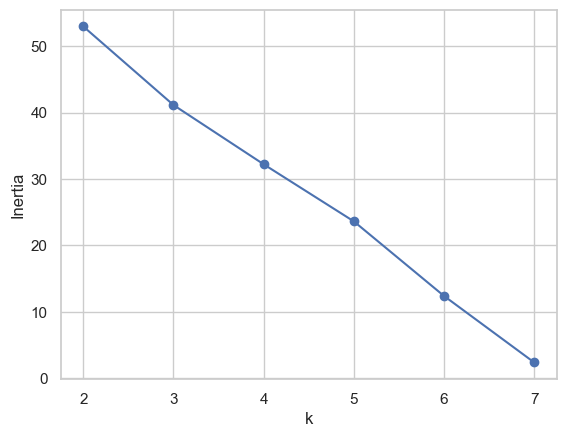

In [10]:
inertias = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

In [11]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.160
k=3, silhouette=0.013
k=4, silhouette=-0.001
k=5, silhouette=-0.063
k=6, silhouette=-0.015
k=7, silhouette=0.067


In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

profiles_df["cluster"] = labels

In [13]:
profiles_df

,username,best_mae_skill,best_rmse_skill,best_smape,best_da,first_mae_skill,delta_rel,slope,mean_window_var,mean_prompt_length,prompt_growth,best_smape_inv,window_stability,cluster
0,Artyom2307,0.196173,0.148175,1.672,0.600,-0.275898,1.711033,0.050340,0.331280,166.909091,0.000000,-1.672,-0.331280,0
1,ChingisBadmaev,0.233496,0.215216,1.658,0.800,0.023111,9.103241,0.000851,0.118559,50.000000,-5.250000,-1.658,-0.118559,2
2,DA_maximizer,0.227967,0.176307,1.684,0.600,0.113789,1.003422,0.010880,0.066000,593.100000,9.578947,-1.684,-0.066000,0
3,MAE_minimizer,0.172110,0.120061,1.841,0.667,-0.073784,3.332614,0.001012,0.700723,1213.454545,-79.300000,-1.841,-0.700723,0
4,SMAPE_minimizer,0.344247,0.323243,1.484,0.800,-0.212720,2.618309,0.006493,0.202806,577.062500,-0.333333,-1.484,-0.202806,0
5,Zebrabug,0.020785,-0.018895,1.854,0.667,-0.031775,1.654148,0.037793,0.877223,378.750000,-214.666667,-1.854,-0.877223,1
6,dmtrpolovnikov,0.182104,0.106443,1.819,0.733,-0.151976,2.198244,-0.043339,0.101833,92.857143,-77.333333,-1.819,-0.101833,3
7,zoghnick,0.102061,0.028174,1.837,0.600,-0.381405,1.267591,0.015063,0.624597,114.600000,-1.444444,-1.837,-0.624597,4


In [14]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_scaled.columns
)

In [15]:
cluster_summary = profiles_df.groupby("cluster").mean(numeric_only=True)
cluster_summary

,best_mae_skill,best_rmse_skill,best_smape,best_da,first_mae_skill,delta_rel,slope,mean_window_var,mean_prompt_length,prompt_growth,best_smape_inv,window_stability
cluster,,,,,,,,,,,,
0,0.235124,0.191947,1.67025,0.66675,-0.112153,2.166344,0.017181,0.325202,637.631534,-17.513596,-1.67025,-0.325202
1,0.020785,-0.018895,1.85400,0.66700,-0.031775,1.654148,0.037793,0.877223,378.750000,-214.666667,-1.85400,-0.877223
2,0.233496,0.215216,1.65800,0.80000,0.023111,9.103241,0.000851,0.118559,50.000000,-5.250000,-1.65800,-0.118559
3,0.182104,0.106443,1.81900,0.73300,-0.151976,2.198244,-0.043339,0.101833,92.857143,-77.333333,-1.81900,-0.101833
4,0.102061,0.028174,1.83700,0.60000,-0.381405,1.267591,0.015063,0.624597,114.600000,-1.444444,-1.83700,-0.624597


In [16]:
groups = [
    profiles_df[profiles_df.cluster == c]["delta_rel"]
    for c in profiles_df.cluster.unique()
]

f_stat, p_value = f_oneway(*groups)
print("ANOVA p-value:", p_value)

ANOVA p-value: 0.039346081144927686


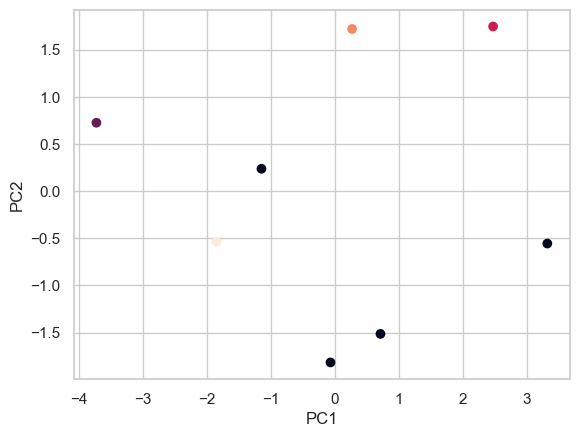

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

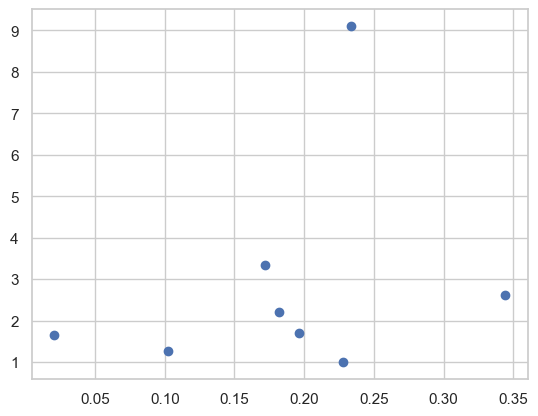

In [18]:
plt.scatter(profiles_df["best_mae_skill"],
            profiles_df["delta_rel"])

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [45.0, 45.0, 62.5, 62.5],
  [30.0, 30.0, 53.75, 53.75],
  [10.0, 10.0, 41.875, 41.875]],
 'dcoord': [[0.0, 3.7264915455154135, 3.7264915455154135, 0.0],
  [0.0, 4.0392061557676415, 4.0392061557676415, 0.0],
  [0.0, 2.182292227228033, 2.182292227228033, 0.0],
  [0.0, 3.2710973507681462, 3.2710973507681462, 2.182292227228033],
  [0.0, 4.3428231881702395, 4.3428231881702395, 3.2710973507681462],
  [4.0392061557676415,
   5.380738933607089,
   5.380738933607089,
   4.3428231881702395],
  [3.7264915455154135,
   7.107962607797285,
   7.107962607797285,
   5.380738933607089]],
 'ivl': ['1', '4', '3', '5', '6', '7', '0', '2'],
 'leaves': [1, 4, 3, 5, 6, 7, 0, 2],
 'color_list': ['C1', 'C2', 'C3', 'C3', 'C3', 'C0', 'C0'],
 'leaves_color_list': ['C1', 'C1', 'C2', 'C2', 'C3', 'C3', 'C3', 'C3']}

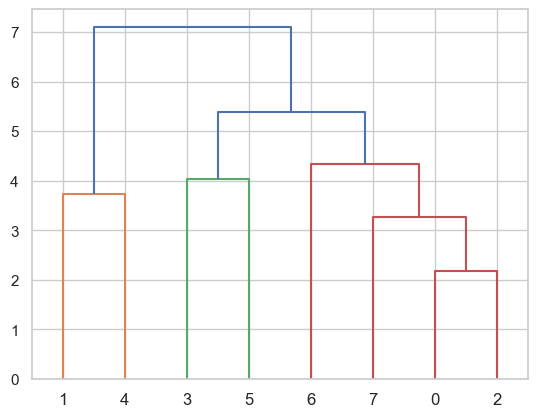

In [19]:
Z = linkage(X_scaled, method="ward")

dendrogram(Z)

In [20]:
profiles = []
    
for user_id, g in df.groupby("username"):
    
    g = g.sort_values("attempt_idx")
    
    # ---- качество (Q) ----
    best_idx = g["mae_skill"].idxmax()
    best_row = g.loc[best_idx]
    Q = best_row["mae_skill"]
    
    # ---- старт ----
    first_row = g.iloc[0]
    first_skill = first_row["mae_skill"]
    
    # ---- относительное улучшение (A) ----
    if first_skill != 0:
        A = (Q - first_skill) / abs(first_skill)
    else:
        A = 0
    
    # ---- наклон (T) ----
    if len(g) > 1:
        t = np.arange(1, len(g)+1)
        y = g["mae_skill"].values
        T = np.polyfit(t, y, 1)[0]
    else:
        T = 0
    
    # ---- устойчивость ----
    mean_var = g["mae_skill_var"].mean()
    Stability = 1 - (mean_var / (abs(Q) + 1e-8))
    
    profiles.append({
        "username": user_id,
        "Q_best_skill": Q,
        "A_relative_improvement": A,
        "T_slope": T,
        "Stability": Stability,
        "first_skill": first_skill
    })

profiles_df = pd.DataFrame(profiles)

In [21]:
def rename_to_ps(username):
    sl = {
        "SMAPE_minimizer": "P1",
        "ChingisBadmaev": "P2",
        "DA_maximizer": "P3",
        "MAE_minimizer": "P4",
        "Artyom2307": "P5",
        "Zebrabug": "P6",
        "dmtrpolovnikov": "P7",
        "zoghnick": "P8"
    }
    return sl[username]

profiles_df['username'] = profiles_df['username'].apply(rename_to_ps)

In [22]:
profiles_df

,username,Q_best_skill,A_relative_improvement,T_slope,Stability,first_skill
0,P5,0.196173,1.711033,0.050340,-0.688715,-0.275898
1,P2,0.233496,9.103241,0.000851,0.492246,0.023111
2,P3,0.227967,1.003422,0.010880,0.710483,0.113789
3,P4,0.172110,3.332614,0.001012,-3.071360,-0.073784
4,P1,0.344247,2.618309,0.006493,0.410870,-0.212720
5,P6,0.020785,1.654148,0.037793,-41.203899,-0.031775
6,P7,0.182104,2.198244,-0.043339,0.440797,-0.151976
7,P8,0.102061,1.267591,0.015063,-5.119862,-0.381405


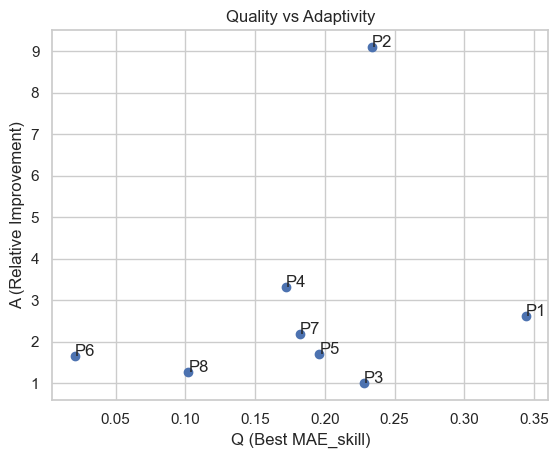

In [81]:
plt.scatter(
    profiles_df["Q_best_skill"],
    profiles_df["A_relative_improvement"]
)

plt.xlabel("Q (Best MAE_skill)")
plt.ylabel("A (Relative Improvement)")
plt.title("Quality vs Adaptivity")

for i, row in profiles_df.iterrows():
    plt.text(row["Q_best_skill"], row["A_relative_improvement"], str(row["username"]))


plt.savefig("QvsA")
plt.show()

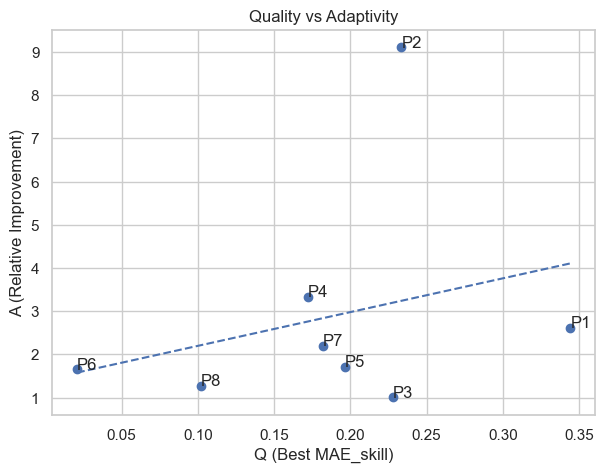

In [25]:
Q = profiles_df["Q_best_skill"].values
A = profiles_df["A_relative_improvement"].values

beta, alpha = np.polyfit(Q, A, 1)

Q_line = np.linspace(min(Q), max(Q), 100)
A_line = beta * Q_line + alpha

plt.figure(figsize=(7,5))
plt.scatter(Q, A)

for i, row in profiles_df.iterrows():
    plt.text(row["Q_best_skill"], row["A_relative_improvement"], str(row["username"]))

plt.plot(Q_line, A_line, linestyle='--')

plt.xlabel("Q (Best MAE_skill)")
plt.ylabel("A (Relative Improvement)")
plt.title("Quality vs Adaptivity")
plt.grid(True)
plt.savefig("QvsA")
plt.show()

In [78]:
r, p = pearsonr(
    profiles_df["first_skill"],
    profiles_df["A_relative_improvement"]
)

print("Correlation first_skill vs improvement:")
print("r =", round(r, 3))
print("p =", round(p, 4))

Correlation first_skill vs improvement:
r = 0.337
p = 0.4149


In [79]:
r2, p2 = pearsonr(
    profiles_df["Stability"],
    profiles_df["Q_best_skill"]
)

print("Correlation stability vs quality:")
print("r =", round(r2, 3))
print("p =", round(p2, 4))

Correlation stability vs quality:
r = 0.764
p = 0.0273


In [83]:
r3, p3 = pearsonr(
    profiles_df["A_relative_improvement"],
    profiles_df["Q_best_skill"]
)

print("Correlation A vs Q:")
print("r =", round(r3, 3))
print("p =", round(p3, 4))

Correlation A vs Q:
r = 0.283
p = 0.4967
